<a href="https://colab.research.google.com/github/milicak/Data_Analysis_Course/blob/main/10_Simple_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import machine-learning packages
import torch
from torch import nn

# Import plotting packages
from IPython.display import Image, HTML
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import time
import base64
import numpy as np

%matplotlib inline

In [3]:
# We create many data points, as neural networks need lot of data to train from scratch.
n = 10000
x = torch.ones(n, 1)

# uniformly sample x points between -1 and 1.
# Underscore functions in pytorch means replace the value (update)
x = x.uniform_(-1.0, 1)

y = torch.sin(x * 2 * torch.pi) + 0.1 * torch.rand(n, 1)

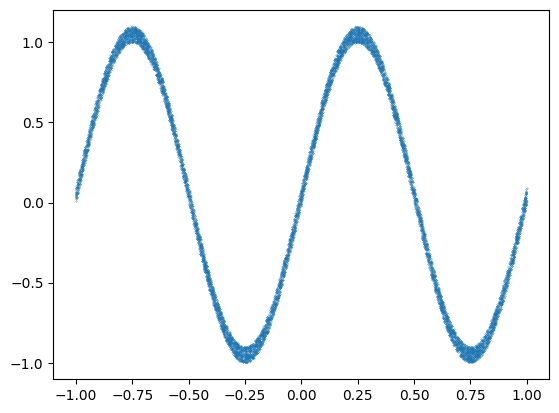

In [4]:
plt.plot(x[:, 0], y, ".", markersize=0.5)

In [25]:
# design consists of 3 hidden dense layers, two of which have a non-linear Relu activation function.
class Simple_Neural_Net(nn.Module):
    def __init__(self):
        N = 50;
        super().__init__()
        self.Dense1 = nn.Linear(1, N)
        self.Dense2 = nn.Linear(N, N)
        self.Dense3 = nn.Linear(N, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        # This method is automatically executed when
        # we call a object of this class
        x = self.Dense1(x)
        x = self.relu(x)
        x = self.Dense2(x)
        x = self.relu(x)
        x = self.Dense3(x)

        return x

In [26]:
neural_net = Simple_Neural_Net()

In [27]:
net_input = torch.randn(1, 1)
out = neural_net(net_input)
print(
    f"The output of the random input {net_input.item():.4f} from untrained network is: {out.item():.4f}"
)

The output of the random input 1.2355 from untrained network is: 0.0876


In [28]:
# A popular optimizer that is used in many neural networks is the Adam optimizer.
# It is an adaptive learning rate method that computes individual learning rates for different parameters.
# Here we use the Adam optimizer.
learning_rate = 0.005
optimizer = torch.optim.Adam(neural_net.parameters())

In [29]:
# MSE loss function
loss_fn = torch.nn.MSELoss()

In [ ]:
torch.nn.

In [30]:
def train_step(model, loss_fn, optimizer):
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices

    pred = model(x)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    loss = loss.item()
    return loss

In [31]:
epochs = 1000
Loss = np.zeros(epochs)
for t in range(epochs):
    Loss[t] = train_step(neural_net, loss_fn, optimizer)
    if np.mod(t, 200) == 0:
        print(f"Loss at Epoch {t+1} is ", Loss[t])

Loss at Epoch 1 is  0.5156892538070679
Loss at Epoch 201 is  0.05509819835424423
Loss at Epoch 401 is  0.0032586425077170134
Loss at Epoch 601 is  0.0010743197053670883
Loss at Epoch 801 is  0.0009036890114657581


In [32]:
# Generate some points where the predictions of the model will be tested.
# Here we pick the testing domain to be larger than the training domain to check if the model
# has any skill at extrapolation.
x_test = torch.linspace(-1.5, 1.5, 501).reshape(501, 1)

# Generate the predictions from the trained model.
pred = neural_net(x_test).detach().numpy()

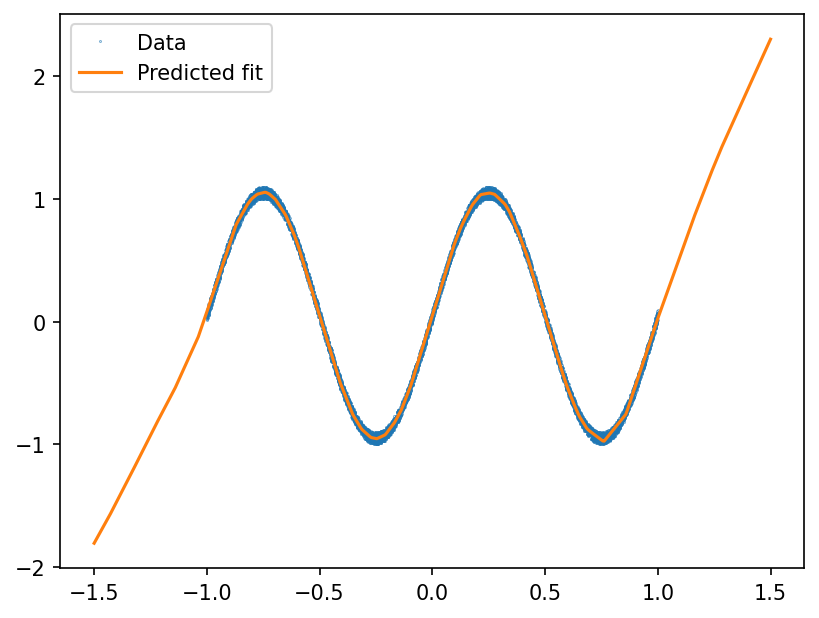

In [33]:
plt.figure(dpi=150)

plt.plot(x, y, ".", markersize=0.5, label="Data")
plt.plot(x_test, pred, markersize=0.5, label="Predicted fit")

plt.legend()

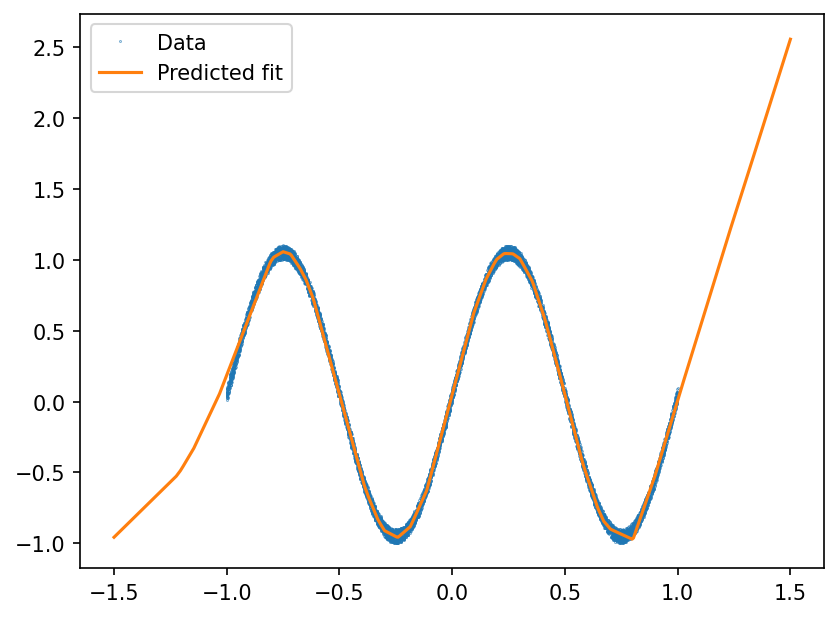

In [12]:
plt.figure(dpi=150)

plt.plot(x, y, ".", markersize=0.5, label="Data")
plt.plot(x_test, pred, markersize=0.5, label="Predicted fit")

plt.legend()

In [34]:
# design consists of 2 hidden dense layers, two of which have a non-linear Relu activation function.
class Simple_Neural_Net_two(nn.Module):
    def __init__(self):
        super().__init__()
        self.Dense1 = nn.Linear(1, 30)
        self.Dense2 = nn.Linear(30, 30)
        self.Dense_Output = nn.Linear(30, 1) # Renamed to avoid confusion, acts as the output layer after the hidden layers

        self.relu = nn.ReLU()

    def forward(self, x):
        # This method is automatically executed when
        # we call a object of this class
        x = self.Dense1(x)
        x = self.relu(x)
        x = self.Dense2(x)
        x = self.relu(x)
        x = self.Dense_Output(x)

        return x

In [35]:
neural_net_two = Simple_Neural_Net_two()
optimizer_two = torch.optim.Adam(neural_net_two.parameters())
def train_step_two(model, loss_fn, optimizer):
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices

    pred = model(x)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer_two.step()
    optimizer_two.zero_grad()

    loss = loss.item()
    return loss

In [36]:
epochs = 1000
Loss = np.zeros(epochs)
for t in range(epochs):
    Loss[t] = train_step_two(neural_net_two, loss_fn, optimizer)
    if np.mod(t, 200) == 0:
        print(f"Loss at Epoch {t+1} is ", Loss[t])

Loss at Epoch 1 is  0.5318732261657715
Loss at Epoch 201 is  0.1597432792186737
Loss at Epoch 401 is  0.051300983875989914
Loss at Epoch 601 is  0.020175660029053688
Loss at Epoch 801 is  0.005903149954974651


In [37]:
# Generate the predictions from the trained model.
pred_two = neural_net_two(x_test).detach().numpy()

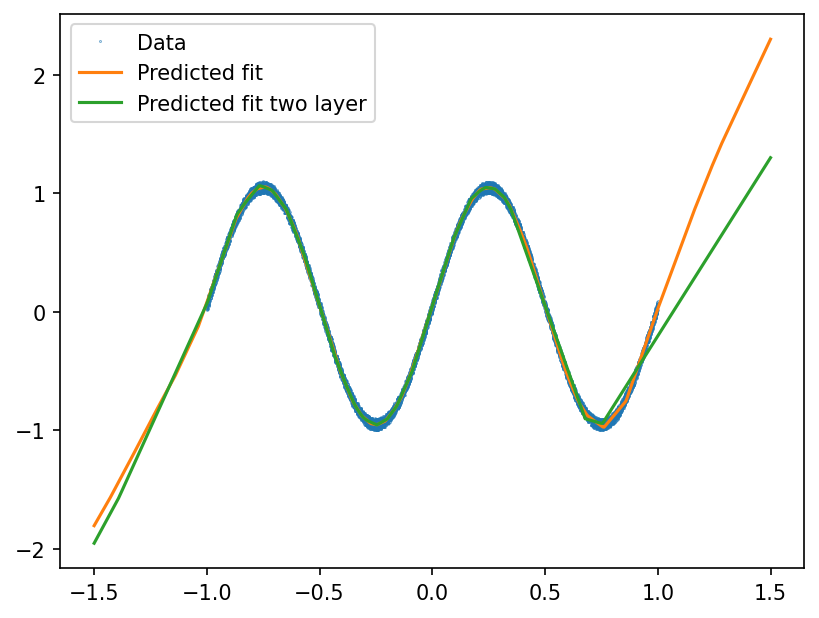

In [38]:
plt.figure(dpi=150)

plt.plot(x, y, ".", markersize=0.5, label="Data")
plt.plot(x_test, pred, markersize=0.5, label="Predicted fit")
plt.plot(x_test, pred_two, markersize=0.5, label="Predicted fit two layer")

plt.legend()